# Day 5 Project — Mini AI Harness
Everything from 5.1 to 5.6 in one place: one runtime, several agents, scoped tools, a policy, events,
a checkpoint carrying an approval, MCP behind the same boundary. Then you add a third agent and
change no harness code at all.

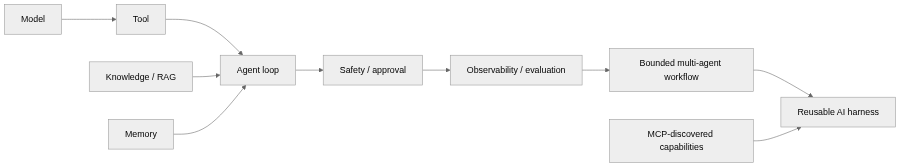

*D18 — how the five days stack: model, tools, knowledge, memory, safety, evaluation, multi-agent, harness*

### The same words, in production

| This course | Common production terminology |
|---|---|
| Provider adapter | model client / provider layer |
| Agent configuration | agent definition or profile |
| Harness runtime | agent runtime, orchestration layer |
| Tool registry | tool or plugin registry |
| Policy | authorization or guardrail middleware |
| Events | tracing / telemetry |
| Checkpoint store | durable execution, state persistence |
| MCP client | protocol integration layer |

The classroom harness is deliberately not a platform: no enterprise identity, sandboxing or
deployment. Its purpose is to make the boundaries visible, so you can open an unfamiliar SDK and find
where *its* model calls, tools, policy, state and events live.

### Step 1 — Assemble the harness once

Three objects, and every agent after this reuses them.

In [ ]:
project_registry = build_demo_registry()
project_events = EventStore()
project_runtime = HarnessRuntime(project_registry, MockProvider(), project_events, CheckpointStore())

print("Registry holds:", [s.name for s in project_registry.discover()])
print("Runtime       :", type(project_runtime).__name__, "with", type(project_runtime.provider).__name__)
print()
for name, prompt in [("research_agent", "harness"), ("task_agent", "Prepare a concise project update")]:
    config = load_config(name)
    result = project_runtime.run(config, prompt)
    print(f"--- {name} ---")
    print("  visible tools:", [s.name for s in project_registry.discover(config.allowed_tools)])
    print("  status       :", result.status, "| output:", result.output[:80])
    print("  events       :", [e["event"] for e in result.events])

### Step 2 — One approval, end to end

The external action pauses, the checkpoint holds the exact arguments, and a separate call carries the
human decision.

In [ ]:
task = load_config("task_agent")
pending = project_runtime.run(task, "Send a synthetic project update")

print("Status       :", pending.status)
print("Approval card:")
print("  tool      :", pending.pending_action["tool"])
print("  arguments :", pending.pending_action["arguments"])
print("  raised by :", pending.pending_action["agent"], "at step", pending.pending_action["steps_used"])

final = project_runtime.resume(pending.run_id, task, approved=True)
print()
print("After approval:", final.status)
print("Tool output   :", final.output)
print("Trace         :", [e["event"] for e in final.events])

### Step 3 — The two small pieces not used yet

A memory interface and the MCP boundary, both minimal. Neither can cause a side effect without going
through policy.

In [ ]:
class SimpleMemory:
    """A deliberately tiny recall interface: overlap of words, nothing more."""
    def __init__(self): self.data = {}
    def add(self, user_id, text): self.data.setdefault(user_id, []).append(text)
    def search(self, user_id, query, limit=3):
        words = set(query.lower().split())
        return sorted(self.data.get(user_id, []),
                      key=lambda item: len(words & set(item.lower().split())), reverse=True)[:limit]

memory = SimpleMemory()
memory.add("fictional_asha", "Prefer concise project updates")
memory.add("fictional_asha", "Lab reports are due on Fridays")
print("Memory recall for 'concise update':", memory.search("fictional_asha", "concise update"))

mcp_tools = await FakeMCPClient().list_tools()
print("MCP discovery                     :", [t.name for t in mcp_tools])
print("MCP call                          :",
      tool_result_payload(await FakeMCPClient().call_tool("course_lookup", {"topic": "harness"})))
print()
print("Both sit OUTSIDE the loop. Neither can bypass policy to cause a side effect.")

### Step 4 — The whole project as one trace

Every event in the shared store, grouped by run: what you show someone who asks what the system did.

In [ ]:
print("Runs recorded in this EventStore:", len(project_events.by_run))
print()
for run_id, rows in project_events.by_run.items():
    print(f"run {run_id}  agent={rows[0]['details'].get('agent', '?')}")
    for row in rows:
        detail = row["details"]
        note = detail.get("decision") or detail.get("tool") or detail.get("error") or ""
        print(f"    {row['event']:<20} {note}")
    print()

### Try it yourself

Add a **third** agent — it looks something up, then wants to email the result — without editing the
registry, the policy or the runtime.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# A configuration is DATA, so a third agent is a new JSON document. The mock_plan
# field is what lets the deterministic provider act on a config it has never seen.
notes_agent = {
    "name": "notes_agent",
    "instructions": "Look up a course note, then request that it be emailed.",
    "allowed_tools": ["lookup_notes", "send_email"],       # one read tool, one external tool
    "max_steps": 4,
    "model": {"provider": "mock", "model": "mock-deterministic", "temperature": 0.0, "max_output_tokens": 300},
    "mock_plan": [
        {"tool": "lookup_notes", "arguments": {"query": "{prompt}"}},        # policy will allow
        {"tool": "send_email", "arguments": {"to": "mentor@example.test",
                                             "subject": "Course note", "body": "{prompt}"}},   # policy will pause
    ],
}
(WORKSPACE / "configs" / "notes_agent.json").write_text(json.dumps(notes_agent, indent=2), encoding="utf-8")
print("Wrote configs/notes_agent.json - it is now loadable like any other agent.")

third = load_config("notes_agent")
result = project_runtime.run(third, "harness")

print()
print("Status:", result.status, "| paused on:", result.pending_action["tool"])
print("Policy decisions this brand-new agent produced:")
for event in result.events:
    if event["event"] == "policy_decision":
        d = event["details"]
        print(f"  {d['tool']:<16} risk={d['risk']:<10} -> {d['decision']}")
print("Full trace:", [e["event"] for e in result.events])
print()
print("Lines of harness code changed to support it: 0")

### Checkpoint

**1. A colleague says 'just add the new agent's logic to the runtime'. What is wrong with that?**

<details><summary>Show answer</summary>

The runtime would start holding application-specific behaviour, so every new agent would mean editing shared, safety-critical code. The third agent needed one JSON document.

</details>

**2. Which responsibility deliberately stays application-specific?**

<details><summary>Show answer</summary>

Which tools an agent may use, and its instructions. The harness owns the mechanism and never decides that *this* agent may send email.

</details>

### Recap

- **Limitation seen:** infrastructure is reusable only if a new application needs no change to it.
- **Layer added:** the complete harness - config, provider, registry, policy, runtime, events, checkpoints, memory, MCP.
- **Evidence:** three agents through one runtime object, one of them written during the section.